In [2]:
import os
import sys
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
sys.path.insert(0,'..')
from scripts.data.classes import fit_empirical_qm
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']    
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELS     = CONFIGS['experiments']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'valid'
QUANTILES  = {50:'#1B2C61',100:'#5BA7DA',200:'#F2C85E',500:'#D42028'}
TAILPCT    = 95

In [4]:
def load(splitsdir):
    train = xr.open_dataset(f'{SPLITSDIR}/train.h5',engine='h5netcdf')[['tp','pr']].load()
    valid = xr.open_dataset(f'{SPLITSDIR}/valid.h5',engine='h5netcdf')[['tp','pr']].load()
    era5  = xr.concat([train.tp,valid.tp],dim='time')
    imerg = xr.concat([train.pr,valid.pr],dim='time')
    era5,imerg = xr.align(era5,imerg,join='inner')
    era5,imerg = era5.values.ravel(),imerg.values.ravel()
    mask = np.isfinite(era5)&np.isfinite(imerg)
    return era5[mask],imerg[mask]

In [5]:
era5,imerg = load(SPLITSDIR)
era5pos = era5[era5>0]
tail    = np.quantile(era5pos,TAILPCT/100)
xeval   = np.linspace(0,era5pos.max(),1000)

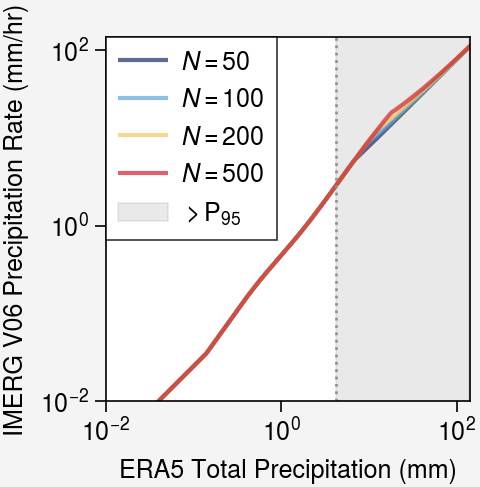

In [16]:
fig,ax  = pplt.subplots(figwidth=2.5)
ax.format(xlabel='ERA5 Total Precipitation (mm)',xlim=(1e-2,140),xticks=[0.01,1,100],xscale='log',xformatter='log',
          ylabel='IMERG V06 Precipitation Rate (mm/hr)',ylim=(1e-2,140),yticks=[0.01,1,100],yscale='log',yformatter='log',
          grid=False)
for nquantiles,color in QUANTILES.items():
    mapping = fit_empirical_qm(era5,imerg,nquantiles=nquantiles)
    ax.plot(xeval,mapping(xeval),label=fr'$\mathit{{N}} = {nquantiles}$',color=color,alpha=0.7,linewidth=1.5)
ax.axvspan(tail,era5pos.max(),color='gray',alpha=0.2,label=fr'$> P_{{{TAILPCT}}}$',zorder=0)
ax.axvline(tail,color='gray',linestyle=':',linewidth=1)
ax.legend(loc='ul',ncols=1)
pplt.show()
fig.save('../figs/fig_S2.jpg')